# NinaPro DB2 — sEMG cross-subject baseline (walkthrough)

Companion notebook to `REPORT.md` and `src/baseline.py`. Loads the cached features, trains the LDA, prints the headline metric, plots the confusion matrix.

Re-running `python src/baseline.py` from the repo root regenerates the cache from raw `.mat` files.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / 'src'))
import baseline as bl

print('Train subjects:', bl.TRAIN_SUBJ)
print('Test subjects :', bl.TEST_SUBJ)
print('Window/hop    :', bl.WIN_MS, 'ms /', bl.HOP_MS, 'ms')

Train subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Test subjects : [11, 12, 13, 14, 15]
Window/hop    : 200 ms / 100 ms


## 1. Inspect a single subject

Schema check (sr=2000 Hz, 12 channels, restimulus/rerepetition present).

In [2]:
emg, rest, rerep = bl.load_subject(1)
print('emg shape :', emg.shape, '   dtype:', emg.dtype)
print('duration  :', emg.shape[0] / bl.SR, 'sec')
print('classes   :', sorted(set(rest.tolist())))
print('reps      :', sorted(set(rerep.tolist())))
print('emg amp   : min={:.4g}  max={:.4g}  std={:.4g}'.format(emg.min(), emg.max(), emg.std()))

emg shape : (1808331, 12)    dtype: float32
duration  : 904.1655 sec
classes   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
reps      : [0, 1, 2, 3, 4, 5, 6]
emg amp   : min=-0.0055  max=0.005498  std=4.18e-05


## 2. Run the pipeline (uses cached features if present)

In [3]:
summary = bl.main(drop_rest=False)
print()
print(summary['headline'])

[baseline] loading train subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


[baseline] loading test subjects [11, 12, 13, 14, 15]

[baseline] train X=(85973, 72), test X=(43016, 72)



[baseline] NinaPro DB2 Exercise 1, train S1-S10 / test S11-S15 (subject-disjoint), N_classes=18, drop_rest=False, macro-F1=0.232 (95% CI [0.226, 0.237]). Single-fit cross-subject baseline; performance is NOT the primary criterion.


[baseline] elapsed 3.2s



NinaPro DB2 Exercise 1, train S1-S10 / test S11-S15 (subject-disjoint), N_classes=18, drop_rest=False, macro-F1=0.232 (95% CI [0.226, 0.237]). Single-fit cross-subject baseline; performance is NOT the primary criterion.


## 3. Confusion matrix

Per-class confusion is more actionable than a single F1 number — see REPORT §4 (failure modes).

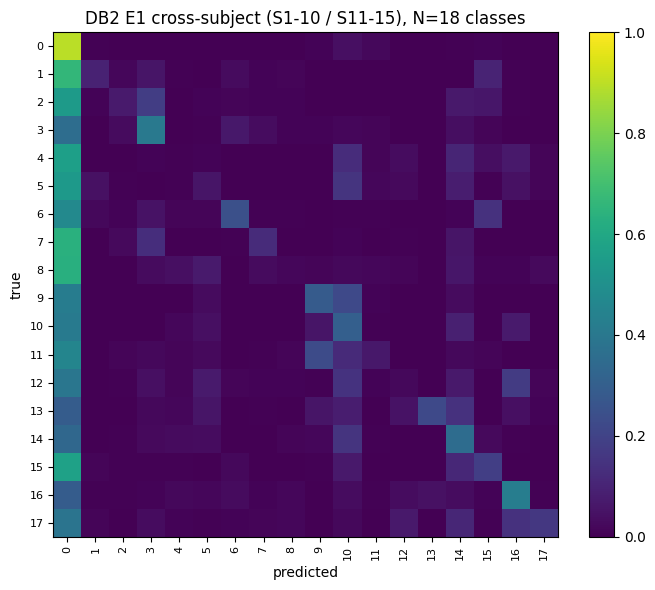

In [4]:
z = np.load('artifacts/confusion_matrix_withrest.npz')
cm = z['cm']; labels = z['labels']
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cmn, vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'DB2 E1 cross-subject (S1-10 / S11-15), N={len(labels)} classes')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=120)
plt.show()

## 4. Without-rest variant

Drops the dominant rest class (label 0). Closer to literature comparisons.

In [5]:
summary_nr = bl.main(drop_rest=True)
print()
print(summary_nr['headline'])

[baseline] loading train subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


[baseline] loading test subjects [11, 12, 13, 14, 15]


[baseline] train X=(42238, 72), test X=(23172, 72)



[baseline] NinaPro DB2 Exercise 1, train S1-S10 / test S11-S15 (subject-disjoint), N_classes=17, drop_rest=True, macro-F1=0.212 (95% CI [0.207, 0.217]). Single-fit cross-subject baseline; performance is NOT the primary criterion.


[baseline] elapsed 2.2s



NinaPro DB2 Exercise 1, train S1-S10 / test S11-S15 (subject-disjoint), N_classes=17, drop_rest=True, macro-F1=0.212 (95% CI [0.207, 0.217]). Single-fit cross-subject baseline; performance is NOT the primary criterion.


---
**Reminder.** Macro-F1 here is a **single** cross-subject fit on Exercise 1 with N_test=5 held-out subjects. It is not a benchmark number; it is a system-design starting point. See `REPORT.md` §4 for the implications and the proposed CNN/calibration follow-up.